# 04 — Mælanlegt í stað spáðs (the observable-input nowcast, Phase 3)

By mid-month a share of the basket is **observable rather than forecastable**. This
notebook wires in the first observable — fuel — and shows exactly why observables and
the fiscal calendar must arrive together.

| Input | Source | Status |
|---|---|---|
| Eldsneyti (CP0722, ~3.5%) | Gasvaktin open data — every retail price change since 2016 | **live, calibrated** |
| Flugfargjöld (CP073, ~3.9%) | Icelandair KEF-origin lowest fares (SSR page parse) | **collecting** (`airfares.py`); calibration once ≥2 windows |
| Matvörur (CP011x, ~13.7%) | Krónan mirror (home_app Supabase) | **collecting** (`groceries.py`); first m/m Sept 2026 |
| Administered steps | `config/fiscal_calendar.yaml` | scaffolded; Jan-2026 steps realized & quantified |

No placeholder data anywhere: pending sources return empty rather than synthetic numbers.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}" if abs(x) < 1e6 else f"{x:,.0f}")

# Okabe-Ito palette (colorblind-safe); recessive grid per house chart style
C = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
     "red": "#D55E00", "pink": "#CC79A7", "sky": "#56B4E9", "black": "#222222"}
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})


In [2]:
from vnv import ingest, models, nowcast, fuel

head = ingest.load_headline()
sub_new = ingest.load_sub_new()
panel_old = ingest.load_panel_old()
spliced = ingest.load_sub_spliced()
g = models.build_component_history(spliced, panel_old, sub_new)
last_m = g.index.max()


## Fuel: ten years of pump prices vs the published subindex

Gasvaktin logs every verified pump-price change per retailer. We average list prices
across retailers (Costco excluded — not in Hagstofa's outlet set), take the mean over
the collection window (days 1–15), and regress the published subindex m/m on it.


calibration (2016–2025, ex 2026-01/02): n=115   published = -0.025 + 1.239 × scraped   resid SD = 0.86pp
error budget at ~3.5% weight: 0.030pp on the headline


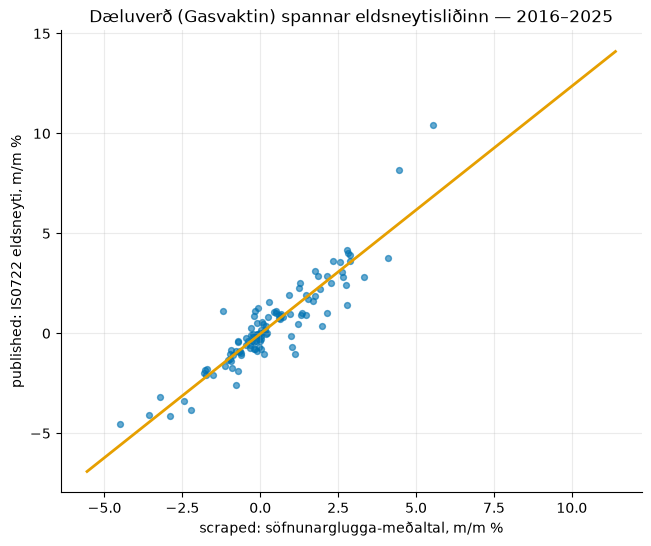

In [3]:
bensin = fuel.scraped_mm("bensin95")
diesel = fuel.scraped_mm("diesel")
mix = (2/3) * bensin + (1/3) * diesel
pub_e = panel_old[panel_old.code == "IS0722"].set_index("manudur").manadarbreyting

cal = nowcast.calibrate_fuel()
print(f"calibration (2016–2025, ex 2026-01/02): n={cal.n_obs}   "
      f"published = {cal.alpha:+.3f} + {cal.beta:.3f} × scraped   resid SD = {cal.resid_sd:.2f}pp")
print(f"error budget at ~3.5% weight: {cal.resid_sd * 0.035:.3f}pp on the headline")

df = pd.concat([mix.rename("scraped"), pub_e.rename("published")], axis=1).dropna()
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(df.scraped, df.published, s=18, color=C["blue"], alpha=0.6)
lims = np.array([df.min().min() - 1, df.max().max() + 1])
ax.plot(lims, cal.alpha + cal.beta * lims, color=C["orange"], lw=2)
jan = df.loc[[pd.Period("2026-01", "M")]] if pd.Period("2026-01", "M") in df.index else None
if jan is not None:
    ax.scatter(jan.scraped, jan.published, s=60, color=C["red"], zorder=5)
    ax.annotate("jan 2026\n(skattabreyting)", xy=(jan.scraped.iloc[0], jan.published.iloc[0]),
                xytext=(8, 8), textcoords="offset points", fontsize=9, color=C["red"])
ax.set_xlabel("scraped: söfnunarglugga-meðaltal, m/m %")
ax.set_ylabel("published: IS0722 eldsneyti, m/m %")
ax.set_title("Dæluverð (Gasvaktin) spannar eldsneytisliðinn — 2016–2025")
plt.show()


## The January-2026 lesson: observables and the fiscal calendar are a pair

Backtest h=1 with and without the fuel observable. In normal months the observable
helps. In January 2026 it makes the forecast **worse** — not because the fuel reading
was wrong (it nailed the −26% fall, áhrif −0.94pp) but because the same reform package
introduced the kílómetragjald (CP0724: **+134% m/m, +1.01pp**) and cut the EV subsidy
(CP071: +12.3%, +0.55pp), which the model had no way to see. Observing one leg of a
fiscal package without booking the others is worse than observing neither.
Those steps now live in `config/fiscal_calendar.yaml`.


In [4]:
rows = []
for m in [m for m in g.index if m > pd.Period("2025-01", "M")]:
    g_tr = g[g.index < m]
    w_prev = sub_new[(sub_new.manudur == m - 1) & sub_new.code.isin(models.COMPONENTS)]
    w_prev = w_prev.set_index("code").vaegi
    if len(w_prev) < len(models.COMPONENTS):
        continue
    f = {c: models.forecast_component(models.fit_component(g_tr[c], c), m - 1, 1).iloc[0]
         for c in models.COMPONENTS}
    fmm = pd.DataFrame([f], index=[m])
    hm, _, _ = models.aggregate_bottom_up(fmm, w_prev)
    cal_m = nowcast.calibrate_fuel(train_end=m - 1)
    fmm_o = nowcast.apply_observables(fmm, nowcast.fuel_nowcast(m, cal_m))
    hmo, _, _ = models.aggregate_bottom_up(fmm_o, w_prev)
    rows.append({"manudur": m, "model": hm.iloc[0], "model+fuel": hmo.iloc[0],
                 "actual": head[("CPI", "change_M")].get(m, np.nan)})
bt = pd.DataFrame(rows).set_index("manudur").dropna()

def rmse(c, frame):
    return np.sqrt(((frame[c] - frame.actual) ** 2).mean())

ex_jan = bt.drop(pd.Period("2026-01", "M"))
stats = pd.DataFrame({
    "RMSE all": {c: rmse(c, bt) for c in ["model", "model+fuel"]},
    "RMSE ex jan-2026": {c: rmse(c, ex_jan) for c in ["model", "model+fuel"]},
})
display(bt.round(3))
stats.round(3)


,model,model+fuel,actual
manudur,,,
2025-02,0.7280,0.7150,0.9100
2025-03,0.4720,0.4090,0.3700
2025-04,0.4420,0.4220,0.9300
2025-05,0.3580,0.3260,0.2000
2025-06,0.4340,0.3860,0.8400
2025-07,0.1650,0.1560,0.3200
2025-08,0.1590,0.1820,-0.1500
2025-09,0.1590,0.1310,0.1100
2025-10,0.4920,0.4600,0.4700


,RMSE all,RMSE ex jan-2026
model,0.3750,0.3530
model+fuel,0.4860,0.3280


## Today's nowcast (partial collection window)

In [5]:
target = last_m + 1
fits = {c: models.fit_component(g[c], c) for c in models.COMPONENTS}
fc1 = pd.DataFrame({c: models.forecast_component(fits[c], last_m, 1) for c in models.COMPONENTS})
obs = nowcast.fuel_nowcast(target, cal)
fc1_obs = nowcast.apply_observables(fc1, obs)

latest = sub_new[sub_new.manudur == last_m].set_index("code")
w0 = latest.loc[models.COMPONENTS, "vaegi"]
hm, contribs, _ = models.aggregate_bottom_up(fc1_obs, w0)

tbl = pd.DataFrame({
    "heiti": latest.loc[models.COMPONENTS, "heiti"].str.slice(0, 40),
    "vægi (%)": w0.round(2),
    "m/m spá (%)": fc1_obs.iloc[0].round(2),
    "framlag (pp)": contribs.iloc[0].round(3),
    "uppruni": ["mælt (Gasvaktin)" if c in obs else "líkan" for c in models.COMPONENTS],
})
print(f"h=1 nowcast for {target}: {hm.iloc[0]:+.2f}% m/m "
      f"(fuel observed at {obs['CP0722']:+.2f}%)")
print("NB: collection window still open — fuel reading updates daily until the 15th.")
tbl.sort_values("framlag (pp)", ascending=False)


h=1 nowcast for 2026-08: +0.14% m/m (fuel observed at +0.30%)
NB: collection window still open — fuel reading updates daily until the 15th.


,heiti,vægi (%),m/m spá (%),framlag (pp),uppruni
CP042,042 Reiknuð húsaleiga,20.7400,0.5600,0.1150,líkan
CP03,03 Fatnaður og skófatnaður,3.2900,2.7400,0.0900,líkan
CP05,"05 Húsbúnaður, heimilistæki og þjónusta",3.9000,1.2400,0.0480,líkan
CP01,01 Matur og óáfengir drykkir,15.2500,0.1600,0.0250,líkan
CP13,"13 Persónuleg umhirða, félagsþjónusta og",3.3700,0.6700,0.0230,líkan
CP11,11 Veitingahús og gistiþjónusta,5.6900,0.3800,0.0220,líkan
CP041,041 Greidd húsaleiga,3.6300,0.4700,0.0170,líkan
CP045,"045 Rafmagn, gas og aðrir orkugjafar",2.9800,0.5800,0.0170,líkan
CP06,06 Heilsa,3.9400,0.2900,0.0110,líkan
CP0722,0722 Orkugjafar og smurolíur fyrir farar,2.6100,0.3000,0.0080,mælt (Gasvaktin)


## Pending observables — status, not placeholders

**Groceries (CP011x):** the Krónan catalog mirror (8,295 SKUs, built for home_app) holds
current prices only, so a change-log history table (`kronan_price_history`) now
accumulates in the home_app Supabase project — **applied 2026-08-19**, seeded with 4,413
SKUs, pg_cron daily at 08:30 UTC during collection-window days 1–15 only, storing only
rows whose price changed. Export with `scripts/export_kronan_history.py`; `groceries.py`
then builds a matched-model Jevons index per COICOP class (forward-fill reconstruction,
category mapping defined). First usable m/m estimate: once the history spans two
collection windows (September 2026).

**Airfares (CP073):** the single highest-variance input — now **collecting**. Icelandair's
Icelandic-edition destination pages server-render their lowest KEF-origin ISK fares into
the page HTML (`__NEXT_DATA__`), so `airfares.py` fetches a fixed 12-route set with a plain
GET (Chrome TLS impersonation via `curl_cffi` clears Cloudflare — no API key, no CORS). A
daily scheduled task (`VNV-airfare-collect`, self-limited to days 1–15) accumulates the
panel; `calibrate_airfares()` activates the CP073 override once ≥2 collection windows and
≥6 overlapping months exist. Until then CP073 stays model-driven — still the dominant term
in the h=1 error budget, but the data to fix it is now being logged.

Today's collected fares (lowest KEF→dest, ISK):


In [6]:
from vnv import airfares
q = airfares.load_quotes()
if q.empty:
    print("no quotes yet")
else:
    show = q[["dest", "flight_type", "depart_date", "return_date", "fare_isk"]].copy()
    display(show.sort_values("fare_isk").reset_index(drop=True))
    print("airfare index:", "calibration pending (need ≥2 collection windows)"
          if airfares.airfare_index_mm().empty else airfares.airfare_index_mm().round(2).to_dict())


,dest,flight_type,depart_date,return_date,fare_isk
0,OSL,ROUND_TRIP,2026-10-25,2026-11-15,30531
1,LON,ROUND_TRIP,2027-02-03,2027-02-20,33001
2,CDG,ROUND_TRIP,2026-11-08,2026-11-21,36661
3,CPH,ROUND_TRIP,2026-10-26,2026-11-12,38581
4,BER,ROUND_TRIP,2027-02-01,2027-02-05,42771
5,ARN,ROUND_TRIP,2026-10-15,2026-10-20,44091
6,AMS,ROUND_TRIP,2026-12-08,2027-01-07,47251
7,ALC,ROUND_TRIP,2026-11-05,2026-11-26,49171
8,BCN,ROUND_TRIP,2027-02-09,2027-03-11,50511
9,TFS,ROUND_TRIP,2026-12-07,2026-12-17,55371


airfare index: calibration pending (need ≥2 collection windows)


The scraped fares confirm the mechanism end to end: real KEF-origin ISK prices for a fixed
route basket, collected daily. One month of collection makes the airfare leg live —
addressing the plan's top-ranked variance source.


In [7]:
from vnv import groceries, airfares
print("grocery snapshots on disk:", len(list(groceries.SNAP_DIR.glob('snapshot_*.csv'))
      if groceries.SNAP_DIR.exists() else []))
print("grocery food index:", "EMPTY - awaiting snapshots" if groceries.food_index_mm().empty
      else "data available")
print("airfare quotes on disk:", len(airfares.load_quotes()), "-> index:",
      "EMPTY - awaiting quotes" if airfares.airfare_index_mm().empty else "data available")

import yaml
cal_steps = yaml.safe_load(open(ROOT / "config" / "fiscal_calendar.yaml", encoding="utf-8"))
pd.DataFrame(cal_steps)[["date", "name", "affects", "direction", "status"]]


grocery snapshots on disk: 0
grocery food index: EMPTY - awaiting snapshots
airfare quotes on disk: 12 -> index: EMPTY - awaiting quotes


,date,name,affects,direction,status
0,2026-01,oliugjald og vorugjold a eldsneyti afnumin,[CP0722],down,enacted
1,2026-01,kolefnisgjald haekkad,"[CP0722, CP0451]",up,enacted
2,2026-01,kilometragjald a oll okutaeki,[CP0724],up,realized
3,2026-01,"vorugjold okutaekja breytt, ivilnun rafbila skert",[CP071],up,realized
4,2027-01,"kronutolugjol fjarlaga 2027 (afengisgjald, tob...","[CP021, CP022, CP0722, CP0724]",up,verify
5,2027-01,"gjaldskrar sveitarfelaga og veitna (hiti, rafm...","[CP0451, CP0455, CP044, CP10]",up,verify


### Error budget after Phase 3 so far

| Component | h=1 error source | SD (pp on headline) |
|---|---|---|
| Eldsneyti | calibration residual 0.86pp × ~3.5% | **0.03** (was ~0.10 unobserved) |
| Flugfargjöld/CP073 | unobserved, ±10–20% swings × ~3.9% | ~0.25 — **the binding constraint** |
| Matur | model-only until snapshots accumulate | ~0.08 |
| Admin steps | calendar scaffolded, quantification manual | episodic (±1pp in January) |

The h=1 target of ≤0.15pp RMSE (Phase 5 gate) is not reachable while airfares are
unobserved — that is the next data source to secure, exactly as the plan ranks it.
